# 최종 미션 — 파이썬 재현 노트북
파일명을 `미션재현_이름.ipynb`로 바꾸고 시작하세요.

## 이 노트북의 사용법 ⚠️ 중요

**코드는 여러분이 직접 씁니다.** 주석으로 "무엇을 해야 하는지"만 안내되어 있습니다.

```python
# [해야 할 일] 결측이 몇 개인지 확인
# [힌트] 표의 정보를 요약해주는 메서드 (교재 2-3장)
# [결과] 어떤 컬럼에 몇 개인지 보여야 함

여기에 코드 작성  ← 이 자리를 채우는 게 여러분의 일
```

### ⚠️ 미션은 스스로 수행합니다

**코드 작성과 분석 판단은 질문 대상이 아닙니다.** 오늘은 심사가 진행되는 날이며, 이 부분이 평가 대상입니다.

| 구분 | 질문 가능 여부 |
|---|---|
| 미션 요구사항·제출 형식이 이해되지 않을 때 | ✅ 질문 가능 |
| 데이터 컬럼의 의미가 이해되지 않을 때 | ✅ 질문 가능 |
| 실행 환경 오류 (파일 업로드, Colab 접속 등) | ✅ 질문 가능 |
| **코드를 어떻게 쓰는지** | ❌ 스스로 해결 |
| **어떤 그래프를 골라야 하는지** | ❌ 스스로 판단 |
| **기준값을 얼마로 정해야 하는지** | ❌ 스스로 판단 |
| **문법 오류·에러 해결** | ❌ 스스로 해결 |

**막혔을 때 찾아볼 자료** (전부 배포되어 있습니다)

| 상황 | 참조 |
|---|---|
| Orange3로는 했는데 코드를 모르겠다 | 교재 **4-9 로제타석** (Orange3 ↔ 파이썬 대응표) |
| 문법이 기억 안 난다 | 교재 **2장** (pandas 4동작) / 어제 실습 노트북 |
| 위젯 조작이 기억 안 난다 | Orange3 매뉴얼 **STEP 1~16** |
| 분석 흐름이 막막하다 | 어제 저녁 관찰 노트북 **Q1~Q6** |

> 💡 **한 번에 완성하려 하지 마세요.** 한 줄 쓰고 실행 → 결과 보고 → 다음 줄. 에러는 정상이며, 에러를 읽고 고치는 것도 평가 대상입니다.

### 📚 출처 메모 (NASA 저장소에서 확인한 내용을 여기에)
```
어떤 실험인가: 리튬이온 배터리를 다양한 온도 조건에서 충전과 방전 실험하며, 배터리의 임피던스를 측정해 배터리의 열화(손상) 정도를 평가
제공 기관: NASA Prognostics Center of Excellence (PCoE)
Citation: B. Saha and K. Goebel (2007). “Battery Data Set”, NASA Prognostics Data Repository, NASA Ames Research Center, Moffett Field, CA
원본 형식 → 배포 형식: MATLAB 데이터(.mat) → ZIP 파일(압축) 안에 MATLAB .mat 파일
```

---
## 준비 — 데이터 불러오기
> 이 셀만 완성되어 있습니다. 나머지는 직접 작성하세요.
> 시작 전: 왼쪽 📁 패널에 `battery_M.csv`와 `battery_NASA.csv`를 모두 드래그 업로드!

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

m = pd.read_csv("/content/battery_M_260722.csv")          # PART 1 · 스냅샷
nasa = pd.read_csv("/content/battery_NASA_260722.csv")    # PART 2 · 시계열

print("M   :", m.shape, "  한 행 = 셀 하나")
print("NASA:", nasa.shape, "  한 행 = 셀 하나의 한 사이클")

M   : (30, 9)   한 행 = 셀 하나
NASA: (636, 11)   한 행 = 셀 하나의 한 사이클


---
# PART 1 — M데이터 (스냅샷)
## 필수 재현 ① · 데이터 확인
> Orange3의 **Column Statistics**로 본 것을 코드로 다시 확인합니다.

In [36]:
# ─────────────────────────────────────────────
# [해야 할 일] 데이터의 앞부분을 눈으로 확인
# [힌트] 표의 첫 몇 줄만 보여주는 메서드
# ─────────────────────────────────────────────


In [37]:
m.head()

,cell_id,cycle_count,initial_capacity,current_capacity,soh,internal_resistance,avg_temp,charge_time,batch_no
0,M01,725,2808.1,2583.5,92.0,32.6,30.1,93,2
1,M02,776,2782.8,2379.3,85.5,38.4,32.5,123,1
2,M03,243,2799.5,2617.5,93.5,39.5,27.1,109,2
3,M04,597,2811.9,2266.4,80.6,42.9,33.9,113,1
4,M05,210,2751.7,2724.2,99.0,28.9,27.2,97,3


In [38]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 컬럼의 타입과 결측(Non-Null) 개수 확인
# [힌트] "출석부 훑기" — 교재 2-3장의 세 버튼 중 두 번째
# [결과] 어떤 컬럼에 결측이 몇 개인지 알 수 있어야 함
# ─────────────────────────────────────────────


# ✏️ 확인한 내용 (발표 3·4장 재료): current_capacity에서 3개의 결측치가 확인되었다. 해당 변수는 셀의 성능을 나타내는 지표이므로 결측치를 그대로 사용할 경우 출하 판정과 상관분석 결과에 영향을 줄 수 있다. 따라서 결측치 처리 방법을 고려하여 분석을 진행해야 한다.
#    결측 컬럼: current_capacity 개수: 3개


In [39]:
m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              30 non-null     object 
 1   cycle_count          30 non-null     int64  
 2   initial_capacity     30 non-null     float64
 3   current_capacity     27 non-null     float64
 4   soh                  30 non-null     float64
 5   internal_resistance  30 non-null     float64
 6   avg_temp             30 non-null     float64
 7   charge_time          30 non-null     int64  
 8   batch_no             30 non-null     int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 2.2+ KB


In [40]:
# ─────────────────────────────────────────────
# [해야 할 일] 수치 컬럼의 요약 통계로 이상한 값 찾기
# [힌트] 세 버튼 중 세 번째. min/max를 유심히 볼 것
# [결과] 물리적으로 불가능한 값이 눈에 띄어야 함
# ─────────────────────────────────────────────


# ✏️ 이상치: 컬럼 M12 값             왜 불가능한가: SOH의 물리적 범위는 0에서 100이기에 120이라는 값은 물리적으로 나올 수 없다.


In [41]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 제외한 데이터를 m_clean 이라는 이름으로 만들기
# [힌트] 조건을 걸어 골라내기 = 마스킹 (교재 1-5, 2-5장)
#        SOH는 100%를 넘을 수 없다
# [결과] print로 제거 전/후 행 수를 비교해 보세요
# ─────────────────────────────────────────────
m_clean = m[m["soh"] <= 100]
print("제거 전:", m.shape[0])
print("제거 후:", m_clean.shape[0])


제거 전: 30
제거 후: 29


## 필수 재현 ② · 최종 판정
> Orange3의 **Select Rows**로 한 선별을 코드로 재현합니다. **두 결과가 같아야 정상입니다.**

In [42]:
# ─────────────────────────────────────────────
# [해야 할 일] 내가 Orange3에서 정한 기준을 조건으로 옮겨 최종 셀 선별
# [힌트] 조건이 2개 이상이면 각각 괄호로 감싸고 & 로 연결
#        df[(조건1) & (조건2)]  ← 괄호 빠뜨리면 에러 (오늘의 1등 에러)
# [결과] 선별된 셀 수를 출력하고, cell_id와 soh를 확인
# ─────────────────────────────────────────────
final = m_clean[(m_clean['soh'] >= 91) | (m_clean['soh'] >= 83) & (m_clean['soh'] < 91) & (m_clean['internal_resistance'] <= 34)]
print("파이썬 선별 결과:", len(final), "개")
final[['cell_id', 'soh', 'internal_resistance']]


파이썬 선별 결과: 20 개


,cell_id,soh,internal_resistance
0,M01,92.0,32.6
2,M03,93.5,39.5
4,M05,99.0,28.9
6,M07,98.2,31.2
7,M08,99.0,25.1
8,M09,96.4,26.4
10,M11,92.3,36.6
12,M13,96.3,26.5
13,M14,93.9,30.0
14,M15,99.0,24.8


In [43]:
# ─────────────────────────────────────────────
# [해야 할 일] Orange3 결과와 일치하는지 대조
# ─────────────────────────────────────────────
# ✏️ Orange3 Select Rows의 Data Out 셀 수: 20개
# ✏️ 파이썬 len(final): 20개
# ✏️ 일치? 예
#    → 아니오라면: 부등호 방향(>= vs >), 기준값, 조건 개수를 하나씩 대조해 보세요


---
# 관문 ① · 기준 민감도 ★변별
### "그 기준, 흔들리면 결과가 얼마나 달라지나요?"

기준값 하나로 판정하고 끝내면 평범합니다. **기준이 얼마나 예민한지 수치로** 보여주세요.

In [44]:
# ─────────────────────────────────────────────
# [해야 할 일] 내 기준값을 -3 / 그대로 / +3 으로 바꿔가며
#              각각 몇 개가 통과하는지 표처럼 출력
#
# [생각해볼 것] 같은 코드를 값만 바꿔 3번 쓰는 것보다,
#               값 목록을 만들어 반복시키는 게 낫지 않을까?
#               (어제 배운 for문 — 리스트를 하나씩 꺼내 쓰기)
#
# [결과 예시]
#   soh >= 88 | soh < 88 & soh >= 80 & internal_resistance <=34 : 통과 21개 / 탈락 9개
#   soh >= 91 | soh < 91 & soh >= 83 & internal_resistance internal_resistance <=34 : 통과 20개 / 탈락 10개
#   soh >= 94 | soh < 94 & soh >= 86 & internal_resistance internal_resistance <=34 : 통과 22개 / 탈락 7개
# ─────────────────────────────────────────────


# ✏️ 발표 7장 문장: "기준을 3%p 낮추면 __개가 더 통과합니다.
#                    그만큼 예민한 경계이므로 __를 근거로 __로 정했습니다"


In [45]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 내 기준 경계에 아슬아슬하게 걸린 셀 찾기
# [힌트] 기준값 ±2 범위에 있는 셀만 골라내면 됩니다 (조건 2개)
# [왜?] "이 셀은 왜 탈락시켰나요?" 질문에 사례로 답할 수 있습니다
# ─────────────────────────────────────────────



---
# 관문 ② · 결측의 영향 ★변별
### "빈칸을 채운 게 답을 바꾸지 않았나요?"

결측을 평균으로 채우고 넘어가면 놓치는 게 있습니다.

In [46]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 결측이 있던 셀들이 어떤 값을 가졌는지 확인
# [힌트] 결측 여부를 판단하는 메서드가 있습니다 (NaN인가?)
#        그 결과를 마스킹 조건으로 쓰면 결측 행만 골라집니다
# [보고 싶은 것] 그 셀들의 cell_id, soh, internal_resistance
# ─────────────────────────────────────────────


# ✏️ 결측 셀들의 SOH는 합격 경계 근처인가, 확실한 불합격인가?


In [47]:
# ─────────────────────────────────────────────
# [해야 할 일 2] 결측을 두 가지 방식으로 처리하고 최종 판정을 비교
#   ⓐ 평균으로 채우기  → 내 기준 적용 → 몇 개 통과?
#   ⓑ 해당 행 제외하기 → 내 기준 적용 → 몇 개 통과?
#
# [힌트] 빈칸 채우기 / 빈칸 있는 행 버리기에 해당하는 메서드가 각각 있습니다
#        (교재 4-9 로제타석의 '결측 채우기' 행 참고)
# [결과] 두 방식의 최종 셀 수를 나란히 출력
# ─────────────────────────────────────────────


# ✏️ 판정이 달라졌는가? 나는 어느 쪽을 택했고 왜인가:


---
# 관문 ③ · 함정 회피 ★변별
### "상관 1위가 정말 원인인가요?"

이 데이터에는 **의도적으로 심어둔 함정**이 있습니다. 순위표만 보면 걸립니다.

In [48]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 "제거하기 전(m)"과 "제거한 후(m_clean)"의
#              SOH 상관 순위를 각각 구해서 비교
#
# [힌트] 상관은 corr() — 단, cell_id는 글자라 계산에서 빼야 합니다
#        특정 열을 빼는 방법: drop(columns=[...])
#        SOH 기준 순위만 보려면 결과에서 'soh' 열을 뽑고 정렬
# [결과] 두 순위표를 나란히 출력해 어떤 변수의 순위가 크게 움직였는지 확인
# ─────────────────────────────────────────────

print("── 이상치 포함 ──")
print(m.drop(columns=['cell_id']).corr()['soh'].sort_values().round(2))
clean_m = m[m['soh'] <= 100]          # 마스킹으로 이상치 제거
print("\n── 이상치 제거 후 ──")
print(clean_m.drop(columns=['cell_id']).corr()['soh'].sort_values().round(2))


── 이상치 포함 ──
internal_resistance   -0.45
charge_time           -0.26
avg_temp              -0.22
cycle_count           -0.21
initial_capacity       0.03
batch_no               0.41
current_capacity       0.68
soh                    1.00
Name: soh, dtype: float64

── 이상치 제거 후 ──
internal_resistance   -0.84
charge_time           -0.39
initial_capacity      -0.34
avg_temp              -0.34
cycle_count           -0.33
batch_no               0.60
current_capacity       0.99
soh                    1.00
Name: soh, dtype: float64


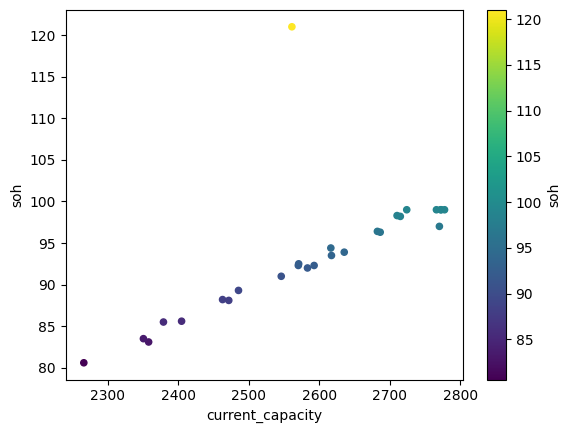

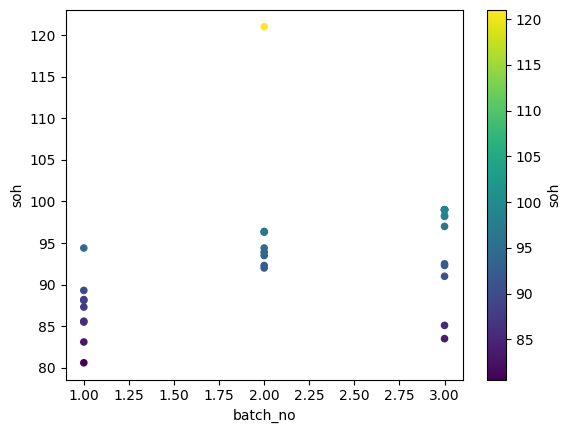

In [49]:
# ─────────────────────────────────────────────
# [해야 할 일] 의심스러운 변수를 산점도로 다시 확인
# [힌트] 산점도는 plot.scatter(x=..., y=...)
# [따져볼 것] 이 변수가 배터리를 늙게 할 "물리적 이유"가 있는가?
#             (예: 생산 배치 번호가 커지면 배터리가 빨리 늙는다? 말이 되는가?)
# ─────────────────────────────────────────────

m.plot.scatter(x='current_capacity', y='soh', c='soh', cmap='viridis')
plt.show()
m.plot.scatter(x='batch_no', y='soh', c='soh', cmap='viridis')
plt.show()


# ✏️ 상관 1위 변수: current_capacity 물리적으로 타당한가? 배터리 열화가 진행될수록 활성 물질 감소, 리튬 손실, 전극 구조 변화 등으로 충전 가능한 용량이 감소하므로 SOH와 높은 상관을 가지는 것은 전기화학적으로 타당하다.
# ✏️ 함정으로 의심되는 변수: current_capacity 배제 이유: SOH와 거의 같은 의미를 가지는 직접적인 열화 결과값에 가깝기 때문이다.
# ✏️ 함정으로 의심되는 변수: batch_no 배제 이유: 단순 식별 번호로 배터리 열화를 발생시키는 전기화학적 또는 제조 공정상의 원인이 아니다. 높은 상관이 나타나더라도 데이터 배치나 우연한 분포 차이에 의한 결과로 판단하여 제외하였다.


---
# PART 2 — NASA 데이터 (시계열)
## 2단계 · 데이터 확인

In [50]:
# ─────────────────────────────────────────────
# [해야 할 일] NASA 데이터의 구조 파악 — 앞부분 + 결측 확인
# [주목] 결측이 있다면 어느 컬럼에, 몇 개나?
# ─────────────────────────────────────────────




In [51]:
nasa.head()

,cell_id,cycle_count,ambient_temp,capacity,soh,internal_resistance,avg_temp,max_temp,discharge_time,min_voltage,is_eol
0,B0005,1,24,1.8565,92.8,NaN,32.6,39.0,61.5,2.612,0
1,B0005,2,24,1.8463,92.3,NaN,32.7,39.0,61.2,2.587,0
2,B0005,3,24,1.8353,91.8,NaN,32.6,38.8,60.9,2.652,0
3,B0005,4,24,1.8353,91.8,NaN,32.5,38.8,60.5,2.593,0
4,B0005,5,24,1.8346,91.7,NaN,32.4,38.7,60.5,2.547,0


In [52]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 셀마다 사이클 수가 다른지 확인
# [힌트] 셀별로 묶어서(groupby) 각 그룹의 최대 사이클을 보면 됩니다
# [왜?] 셀마다 관측 길이가 다르면 비교할 때 주의해야 합니다 (발표 '한계' 재료)
# ─────────────────────────────────────────────


# ─────────────────────────────────────────────
# [해야 할 일 2 · 관문② 심화] 결측이 어디에 있는지 확인 ★
# [힌트] 결측인 행만 골라낸 뒤, 셀별·사이클별로 어디에 몰려 있는지 보세요
#        (groupby로 묶어 min/max 사이클을 보면 구간이 드러납니다)
# [따져볼 것] 결측이 무작위인가, 특정 구간에 몰려 있는가?
#             몰려 있다면 평균으로 채우는 게 왜 위험한가?
# ─────────────────────────────────────────────


# ✏️ 결측 구간:                     평균 대체가 위험한 이유:


In [53]:
cycle_count = nasa.groupby('cell_id')['cycle_count'].max()

print("── 셀별 최대 사이클 ──")
print(cycle_count)

── 셀별 최대 사이클 ──
cell_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: cycle_count, dtype: int64


In [54]:
missing = nasa[nasa.isnull().any(axis=1)]

print("── 결측 데이터 개수 ──")
print(len(missing))

print("\n── 결측 데이터 확인 ──")
print(missing.head())


missing_cell = missing.groupby('cell_id').size()

print("── 셀별 결측 개수 ──")
print(missing_cell)


missing_range = missing.groupby('cell_id')['cycle_count'].agg(['min','max','count'])

print("── 셀별 결측 발생 구간 ──")
print(missing_range)

── 결측 데이터 개수 ──
57

── 결측 데이터 확인 ──
  cell_id  cycle_count  ambient_temp  capacity   soh  internal_resistance  \
0   B0005            1            24    1.8565  92.8                  NaN   
1   B0005            2            24    1.8463  92.3                  NaN   
2   B0005            3            24    1.8353  91.8                  NaN   
3   B0005            4            24    1.8353  91.8                  NaN   
4   B0005            5            24    1.8346  91.7                  NaN   

   avg_temp  max_temp  discharge_time  min_voltage  is_eol  
0      32.6      39.0            61.5        2.612       0  
1      32.7      39.0            61.2        2.587       0  
2      32.6      38.8            60.9        2.652       0  
3      32.5      38.8            60.5        2.593       0  
4      32.4      38.7            60.5        2.547       0  
── 셀별 결측 개수 ──
cell_id
B0005    19
B0006    19
B0007    19
dtype: int64
── 셀별 결측 발생 구간 ──
         min  max  count
cell_id             

## 3단계 · 열화 곡선 그리기 ★ 오늘의 핵심 그래프
> Orange3에서는 산점도로 봤지만, 파이썬에서는 **진짜 선 그래프**를 그릴 수 있습니다.

In [55]:
# ─────────────────────────────────────────────
# [해야 할 일] 셀마다 선을 하나씩 그려서, 사이클에 따른 SOH 변화 표시
#
# [설계 힌트]
#   1) 셀별로 데이터를 나눠야 한다 → groupby로 묶으면 (이름, 데이터) 쌍이 나옵니다
#   2) 각 셀마다 선을 하나씩 → plt.plot(x축값, y축값, label=셀이름)
#   3) EOL 기준선 80%를 가로선으로 → plt.axhline(80, color='red', linestyle='--')
#   4) 범례·축 이름 → plt.legend(), plt.xlabel(), plt.ylabel()
#   5) 마지막에 plt.show()
#
# [결과] 왼쪽 위에서 오른쪽 아래로 흘러내리는 곡선 4개 + 빨간 기준선
# ─────────────────────────────────────────────


# ✏️ 이 그림에서 알게 된 것 한 문장 (발표 8장):


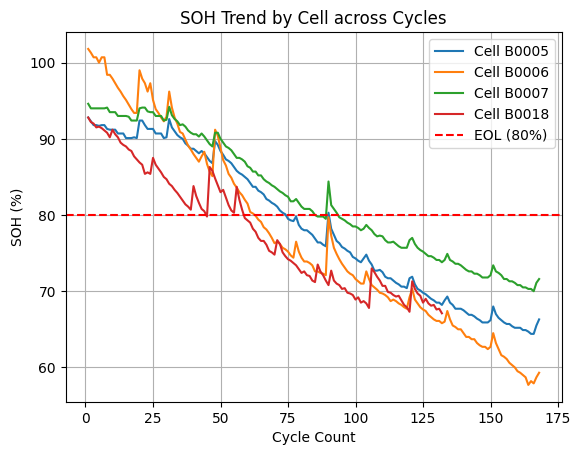

In [56]:



# 셀별로 데이터 분할 및 사이클에 따른 SOH 선 그래프 그리기
for cell_name, cell_data in nasa.groupby('cell_id'):
    plt.plot(
        cell_data['cycle_count'],
        cell_data['soh'],
        label=f'Cell {cell_name}',
    )

#  EOL 기준선 80% 가로선 추가
plt.axhline(80, color='red', linestyle='--', label='EOL (80%)')

# 축 이름 및 범례 설정
plt.xlabel('Cycle Count')
plt.ylabel('SOH (%)')
plt.title('SOH Trend by Cell across Cycles')
plt.legend()
plt.grid(True)

# 그래프 출력
plt.show()

In [57]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 셀이 몇 번째 사이클에 EOL(SOH 80% 미만)에 도달했는지
# [힌트] EOL 여부를 나타내는 컬럼이 이미 있습니다 (is_eol)
#        그 값이 1인 행만 고른 뒤, 셀별로 묶어서 가장 작은 사이클을 찾으면 됩니다
# [결과] 셀 4개의 EOL 도달 사이클
# ─────────────────────────────────────────────


# ✏️ 가장 빨리 죽은 셀: B0018 가장 오래 버틴 셀: B0007 차이: 41사이클


In [58]:

# EOL 여부(is_eol)가 1인 행만 선택
eol_nasa = nasa[nasa['is_eol'] == 1]

# 셀별로 가장 작은 cycle_count 찾기
eol_summary = eol_nasa.groupby('cell_id')['cycle_count'].min()

print('--- 셀별 EOL 도달 사이클 ---')
print(eol_summary)

--- 셀별 EOL 도달 사이클 ---
cell_id
B0005    75
B0006    63
B0007    86
B0018    45
Name: cycle_count, dtype: int64


---
# 관문 ④ · 교차 검증 ★변별
### "PART 1의 발견이 PART 2에서도 성립하나요?"

두 데이터를 따로 분석하고 끝내면 절반입니다. **연결**하세요.

In [59]:
# ─────────────────────────────────────────────
# [해야 할 일] PART 1에서 찾은 열화 신호(변수)가
#              NASA 데이터에서도 같은 방향인지 상관으로 확인
#
# [힌트] 두 데이터 각각에서 해당 변수와 soh의 상관계수를 구해 나란히 출력
# [따져볼 것] 방향(+/-)은 같은가? 강도는? 왜 차이가 날까?
# ─────────────────────────────────────────────


# ✏️ M데이터 상관: internal_resistance NASA 상관: internal_resistance
# ✏️ 나의 해석 (발표 9장):


In [60]:
nasa_clean = nasa[nasa["soh"] <= 100]
print("── 이상치 포함 ──")
print(nasa.drop(columns=['cell_id']).corr()['soh'].sort_values().round(2))
clean_nasa = nasa[nasa['soh'] <= 100]          # 마스킹으로 이상치 제거
print("\n── 이상치 제거 후 ──")
print(clean_nasa.drop(columns=['cell_id']).corr()['soh'].sort_values().round(2))

── 이상치 포함 ──
cycle_count           -0.93
is_eol                -0.87
internal_resistance   -0.71
max_temp              -0.53
avg_temp              -0.51
min_voltage           -0.24
discharge_time         0.95
capacity               1.00
soh                    1.00
ambient_temp            NaN
Name: soh, dtype: float64

── 이상치 제거 후 ──
cycle_count           -0.93
is_eol                -0.87
internal_resistance   -0.71
max_temp              -0.54
avg_temp              -0.52
min_voltage           -0.25
discharge_time         0.95
capacity               1.00
soh                    1.00
ambient_temp            NaN
Name: soh, dtype: float64


In [61]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별로 나눠서 본 상관 vs 전체를 한 덩어리로 본 상관 ★
# [힌트] groupby로 셀을 나눈 뒤, 각 그룹에서 저항-SOH 상관을 구해 비교
# [따져볼 것] 셀마다 값이 크게 다른가? 전체 상관과 차이가 나는가?
#             다르다면 "평균의 함정"일 수 있습니다
# ─────────────────────────────────────────────


# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별 열화 속도(기울기) 비교
# [힌트] (첫 SOH - 마지막 SOH) / 사이클 수, 또는 numpy polyfit으로 직선 맞추기
# ─────────────────────────────────────────────




In [62]:
# 1. 전체 데이터를 한 덩어리로 본 상관계수
overall_corr = nasa['internal_resistance'].corr(nasa['soh'])

# 2. 셀(cell_id)별로 그룹화하여 구한 상관계수
cell_soh_corr = clean_nasa.groupby('cell_id').apply(
    lambda group: group.corr(numeric_only=True)['soh']
)

print(f'전체 합산 상관계수: {overall_corr:.4f}\n')
print('--- 셀별 개별 상관계수 ---')
print(cell_soh_corr)

전체 합산 상관계수: -0.7127

--- 셀별 개별 상관계수 ---
soh      cycle_count  ambient_temp  capacity  soh  internal_resistance  \
cell_id                                                                  
B0005      -0.987635           NaN  0.999995  1.0            -0.929141   
B0006      -0.980362           NaN  0.999997  1.0            -0.982485   
B0007      -0.988065           NaN  0.999994  1.0            -0.961474   
B0018      -0.969624           NaN  0.999994  1.0            -0.558846   

soh      avg_temp  max_temp  discharge_time  min_voltage    is_eol  
cell_id                                                             
B0005   -0.809201 -0.935316        0.975434    -0.487042 -0.899180  
B0006   -0.841727 -0.872777        0.993648    -0.531956 -0.879658  
B0007   -0.588017 -0.746309        0.981817    -0.314521 -0.871575  
B0018   -0.193585 -0.699488        0.992640     0.117394 -0.892156  


/tmp/ipykernel_1683/1276382627.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_soh_corr = clean_nasa.groupby('cell_id').apply(


In [63]:
import numpy as np

# numpy polyfit을 활용한 1차 선형 회귀 기울기 계산 (clean_nasa 기준)
slopes = {}
for cell_id, group in clean_nasa.groupby('cell_id'):
    # x: cycle_count, y: soh
    slope, intercept = np.polyfit(group['cycle_count'], group['soh'], 1)
    slopes[cell_id] = slope

print('--- 셀별 열화 기울기 (% / cycle) ---')
for cell_id, slope in slopes.items():
    print(f'Cell {cell_id}: {slope:.4f} (%/cycle)')

--- 셀별 열화 기울기 (% / cycle) ---
Cell B0005: -0.1933 (%/cycle)
Cell B0006: -0.2500 (%/cycle)
Cell B0007: -0.1635 (%/cycle)
Cell B0018: -0.1964 (%/cycle)


---
# 4단계 · 결론·한계 메모
발표 9~10장에 쓸 내용을 여기에 정리하세요.

In [64]:
결론 = """


"""

한계_3가지 = """
1.
2.
3.
"""

print(결론); print(한계_3가지)






1.
2.
3.



---
## 제출 전 확인

- [ ] **런타임 → 모두 실행** 후 저장 (실행 결과가 남아 있어야 합니다)
- [ ] 필수 재현 ②의 셀 수가 Orange3 결과와 일치
- [ ] 열화 곡선 그래프가 그려졌다
- [ ] 관문 ①~④ 중 시도한 것에 ✏️ 메모를 채웠다
- [ ] 파일명이 `미션재현_이름.ipynb`

> **제출 마감: 23:00** — 파일 → 다운로드 → `.ipynb` 다운로드 후 안내 채널에 업로드

> 완성하지 못한 관문이 있어도 괜찮습니다. **시도한 흔적(코드와 메모)이 남아 있으면 부분 점수**를 받습니다.